# GWP-0.5 Sharpa: closed-loop WebXR sim eval

Closed loop, wam.cpp `ActionChunkExecutor` recipe:
- The policy predicts a 32-step chunk; the sim executes all 32 steps, then re-observes.
- 10 flow-matching steps, shift 5, no CFG.
- 58 training scenes with seeded resets (object xy ±5 cm, yaw ±180°, arm jitter 0.08), identical across checkpoints.

Stages come from sim signals:
- **reach:** a hand came within 3 cm of an object.
- **grasp:** at least 0.5 s of contact while the object was lifted 2 cm or more, or carried 3 cm or more.
- **move:** an object moved at least 5 cm, or a joint turned at least 20°.
- **all three:** reach, grasp and move in the same rollout.

Task completion (placement) waits for the VLM judge.

In [1]:
import glob, json, math, os, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO = Path('/root/OpenWAM'); os.chdir(REPO)
EVAL = REPO / '.sharpa_sim_eval'
RUNS = ['gwp05_full_v1', 'gwp05_full_v2']
TASKS = json.load(open(REPO / 'benchmarks/sharpa_webxr/tasks.json'))
STAGES = ['reach', 'grasp', 'move']

def parse_tag(tag):
    m = re.match(r'(best_val_)?step0*(\d+)_(ema|bf16)$', tag)
    if m:
        return int(m.group(2)), m.group(3), bool(m.group(1))
    return None

rows = []
for run in RUNS:
    for tdir in sorted((EVAL / run).glob('*')):
        p = parse_tag(tdir.name)
        if p is None:
            continue
        step, weights, best = p
        for f in glob.glob(str(tdir / '**' / 'seed_*' / 'signals.json'), recursive=True):
            s = json.load(open(f))
            rj = Path(f).with_name('rollout.json')
            st = s['stage']
            rows.append(dict(run=run, tag=tdir.name, step=step, weights=weights, best_val=best,
                             scene=s['scene_id'], seed=s['seed'], task=TASKS[s['scene_id']]['task'],
                             gpt=bool(TASKS[s['scene_id']]['n_eps'].get('gpt_fleet_depth')),
                             reach=bool(st.get('reach')), grasp=bool(st.get('grasp')), move=bool(st.get('move')),
                             fallen=bool(s.get('fallen_any')), ik=s.get('ik_converged_frac', np.nan),
                             steps=json.load(open(rj))['steps'] if rj.exists() else np.nan,
                             dir=str(Path(f).parent)))
df = pd.DataFrame(rows)
df['all3'] = df.reach & df.grasp & df.move
df['label'] = df.run.str.replace('gwp05_full_', '') + ' ' + df.tag
print('rollouts per tag:', df.groupby('label').size().to_dict())
print(f'{len(df):,} rollouts;', df.groupby('run').tag.nunique().to_dict(), 'checkpoint tags per run')

rollouts per tag: {'v1 step3250_bf16': 580, 'v1 step3250_ema': 58, 'v1 step3500_bf16': 580, 'v1 step4000_bf16': 580, 'v1 step5000_bf16': 580, 'v2 step005000_bf16': 290, 'v2 step005000_ema': 290}
2,958 rollouts; {'gwp05_full_v1': 5, 'gwp05_full_v2': 2} checkpoint tags per run


## Summary per checkpoint

In [2]:
def wilson(k, n, z=1.96):
    p = k / n; d = 1 + z*z/n; c = (p + z*z/(2*n)) / d
    h = z * math.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return c - h, c + h

g = df.groupby(['run', 'tag', 'step', 'weights', 'best_val'])
summ = g.agg(n=('all3', 'size'), seeds=('seed', 'nunique'), reach=('reach', 'mean'), grasp=('grasp', 'mean'),
             move=('move', 'mean'), all3=('all3', 'mean'), fallen=('fallen', 'mean'), ik=('ik', 'mean')).reset_index()
ci = g.all3.agg(['sum', 'size']).apply(lambda r: wilson(r['sum'], r['size']), axis=1)
summ['all3_lo'] = [c[0] for c in ci]; summ['all3_hi'] = [c[1] for c in ci]
summ = summ.sort_values(['run', 'best_val', 'step', 'weights'])
display(summ.style.format({c: '{:.3f}' for c in ['reach', 'grasp', 'move', 'all3', 'all3_lo', 'all3_hi', 'fallen', 'ik']})
        .background_gradient(subset=['all3'], cmap='Greens', vmin=0, vmax=0.7).hide(axis='index'))

run,tag,step,weights,best_val,n,seeds,reach,grasp,move,all3,fallen,ik,all3_lo,all3_hi
gwp05_full_v1,step3250_bf16,3250,bf16,False,580,10,0.967,0.540,0.674,0.502,0.059,0.949,0.461,0.542
gwp05_full_v1,step3250_ema,3250,ema,False,58,1,0.741,0.017,0.707,0.017,0.259,0.211,0.003,0.091
gwp05_full_v1,step3500_bf16,3500,bf16,False,580,10,0.974,0.536,0.709,0.503,0.064,0.944,0.463,0.544
gwp05_full_v1,step4000_bf16,4000,bf16,False,580,10,0.969,0.507,0.657,0.464,0.052,0.954,0.424,0.504
gwp05_full_v1,step5000_bf16,5000,bf16,False,580,10,0.964,0.522,0.638,0.472,0.048,0.951,0.432,0.513
gwp05_full_v2,step005000_bf16,5000,bf16,False,290,5,0.955,0.514,0.721,0.490,0.100,0.810,0.433,0.547
gwp05_full_v2,step005000_ema,5000,ema,False,290,5,0.959,0.445,0.583,0.410,0.055,0.920,0.355,0.468


## Stage rates per checkpoint

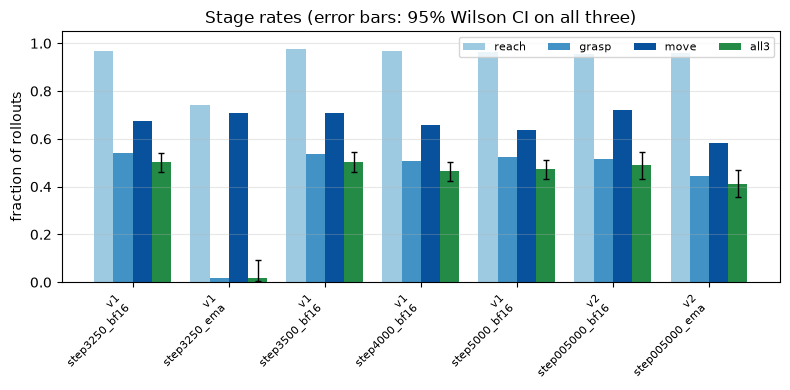

In [3]:
fig, ax = plt.subplots(figsize=(max(8, 0.9 * len(summ)), 4))
x = np.arange(len(summ)); w = 0.2
for i, (k, c) in enumerate(zip(STAGES + ['all3'], ['#9ecae1', '#4292c6', '#08519c', '#238b45'])):
    ax.bar(x + (i - 1.5) * w, summ[k], w, label=k, color=c)
ax.errorbar(x + 1.5 * w, summ.all3, yerr=[summ.all3 - summ.all3_lo, summ.all3_hi - summ.all3], fmt='none', ecolor='k', capsize=2, lw=1)
ax.set_xticks(x, (summ.run.str.replace('gwp05_full_', '') + '\n' + summ.tag).tolist(), rotation=45, ha='right', fontsize=8)
ax.set_ylim(0, 1.05); ax.set_ylabel('fraction of rollouts'); ax.legend(ncol=4, fontsize=8); ax.grid(axis='y', alpha=.3)
ax.set_title('Stage rates (error bars: 95% Wilson CI on all three)')
plt.tight_layout(); plt.show()

## All three vs training step
v2 intermediate checkpoints use 5 seeds; dashed lines are v1 checkpoints (10 seeds).

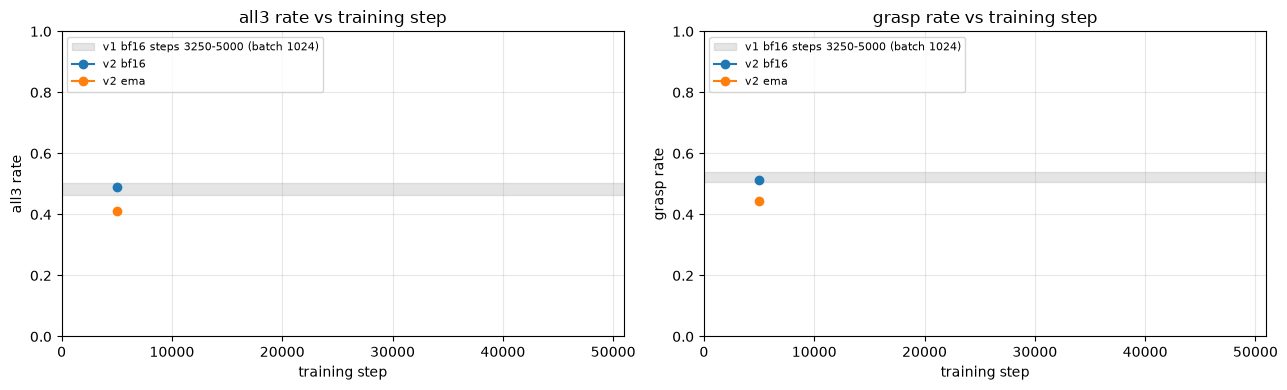

In [4]:
v1 = summ[(summ.run == 'gwp05_full_v1') & (summ.weights == 'bf16')]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ['all3', 'grasp']):
    ax.axhspan(v1[metric].min(), v1[metric].max(), color='gray', alpha=.2,
               label=f'v1 bf16 steps {v1.step.min()}-{v1.step.max()} (batch 1024)')
    for (run, wts), sub in summ[~summ.best_val & (summ.run != 'gwp05_full_v1')].groupby(['run', 'weights']):
        sub = sub.sort_values('step')
        ax.plot(sub.step, sub[metric], 'o-', label=f'{run.replace("gwp05_full_", "")} {wts}')
        if metric == 'all3':
            ax.fill_between(sub.step, sub.all3_lo, sub.all3_hi, alpha=.15)
    ax.set_xlim(0, 51000); ax.set_xlabel('training step'); ax.set_ylabel(f'{metric} rate'); ax.set_ylim(0, 1)
    ax.grid(alpha=.3); ax.legend(fontsize=8, loc='upper left'); ax.set_title(f'{metric} rate vs training step')
plt.tight_layout(); plt.show()

## Where rollouts stop
First stage each rollout failed to reach.

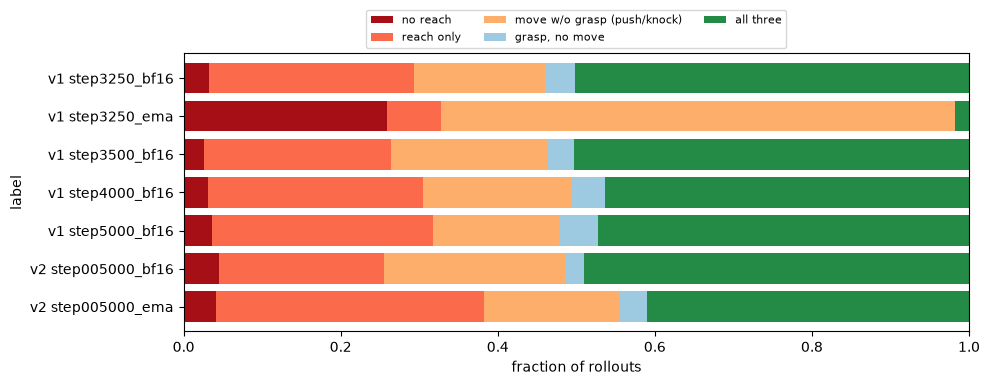

In [5]:
def outcome(r):
    if not r.reach: return 'no reach'
    if not r.grasp and not r.move: return 'reach only'
    if not r.grasp: return 'move w/o grasp (push/knock)'
    if not r.move: return 'grasp, no move'
    return 'all three'
order = ['no reach', 'reach only', 'move w/o grasp (push/knock)', 'grasp, no move', 'all three']
colors = ['#a50f15', '#fb6a4a', '#fdae6b', '#9ecae1', '#238b45']
df['outcome'] = df.apply(outcome, axis=1)
tab = pd.crosstab(df.label, df.outcome, normalize='index').reindex(columns=order, fill_value=0)
tab = tab.loc[summ.apply(lambda r: r.run.replace('gwp05_full_', '') + ' ' + r.tag, axis=1)]
ax = tab.plot.barh(stacked=True, color=colors, figsize=(10, 0.35 * len(tab) + 1.5), width=.8)
ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel('fraction of rollouts'); ax.legend(ncol=3, fontsize=8, loc='lower center', bbox_to_anchor=(.5, 1))
plt.tight_layout(); plt.show()

## Scenes with gpt_fleet_depth data vs simteleop-only scenes

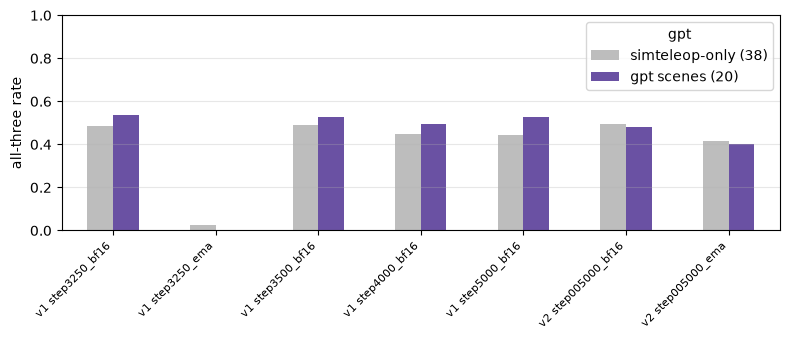

In [6]:
sp = df.groupby(['label', 'gpt']).all3.mean().unstack().rename(columns={True: 'gpt scenes (20)', False: 'simteleop-only (38)'})
sp = sp.loc[tab.index]
ax = sp.plot.bar(figsize=(max(8, 0.8 * len(sp)), 3.5), color=['#bdbdbd', '#6a51a3'])
ax.set_ylabel('all-three rate'); ax.set_ylim(0, 1); ax.grid(axis='y', alpha=.3); ax.set_xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=8); plt.tight_layout(); plt.show()

## Per-scene all-three rate
Rows sorted by mean over checkpoints; ★ marks scenes with gpt_fleet_depth data.

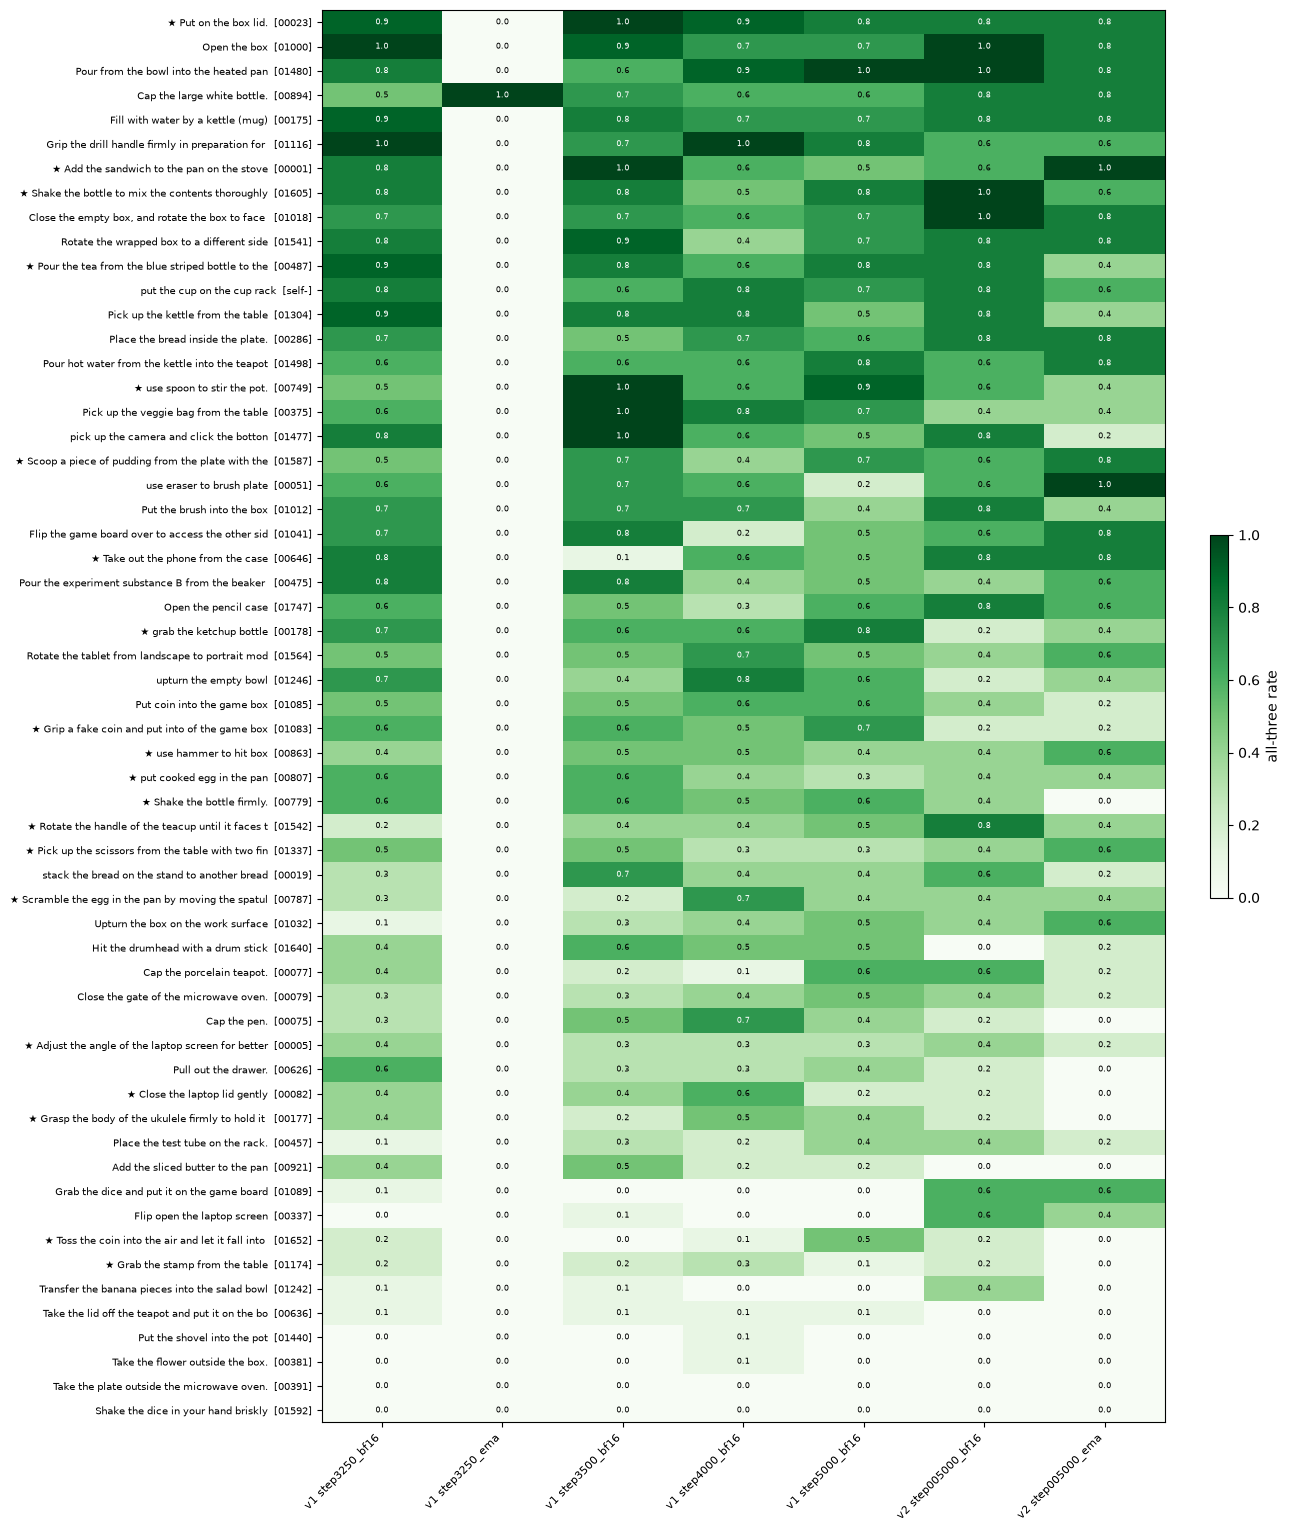

In [7]:
hm = df.pivot_table(index='scene', columns='label', values='all3', aggfunc='mean')[tab.index]
hm = hm.loc[hm.mean(axis=1).sort_values(ascending=False).index]
names = [('★ ' if TASKS[s]['n_eps'].get('gpt_fleet_depth') else '') + TASKS[s]['task'][:48] + f'  [{s[:5]}]' for s in hm.index]
fig, ax = plt.subplots(figsize=(1.0 * hm.shape[1] + 6, 0.24 * len(hm) + 1.5))
im = ax.imshow(hm.values, cmap='Greens', vmin=0, vmax=1, aspect='auto')
ax.set_yticks(range(len(hm)), names, fontsize=7); ax.set_xticks(range(hm.shape[1]), hm.columns, rotation=45, ha='right', fontsize=8)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        v = hm.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=6, color='white' if v > .6 else 'black')
plt.colorbar(im, ax=ax, fraction=.02, label='all-three rate'); plt.tight_layout(); plt.show()

## IK convergence, fallen objects, episode length

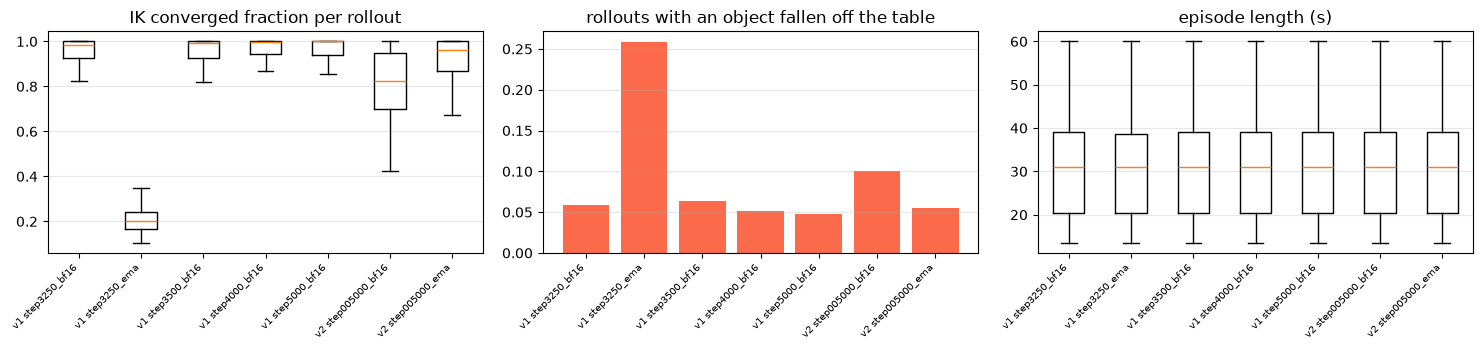

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
labels = list(tab.index)
axes[0].boxplot([df[df.label == l].ik.dropna() for l in labels], showfliers=False)
axes[0].set_title('IK converged fraction per rollout')
axes[1].bar(range(len(labels)), [df[df.label == l].fallen.mean() for l in labels], color='#fb6a4a')
axes[1].set_title('rollouts with an object fallen off the table')
axes[2].boxplot([df[df.label == l].steps.dropna() / 20 for l in labels], showfliers=False)
axes[2].set_title('episode length (s)')
for ax in axes:
    ax.set_xticks(range(1 if ax is not axes[1] else 0, len(labels) + (1 if ax is not axes[1] else 0)), labels, rotation=45, ha='right', fontsize=7)
    ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

## Keyframes: best and worst scenes
The fully evaluated tag with the highest all-three rate, seed 0. Each panel shows 8 of the 16 judge keyframes, with the ego view on the left and the chest view on the right.

checkpoint: gwp05_full_v1 step3500_bf16


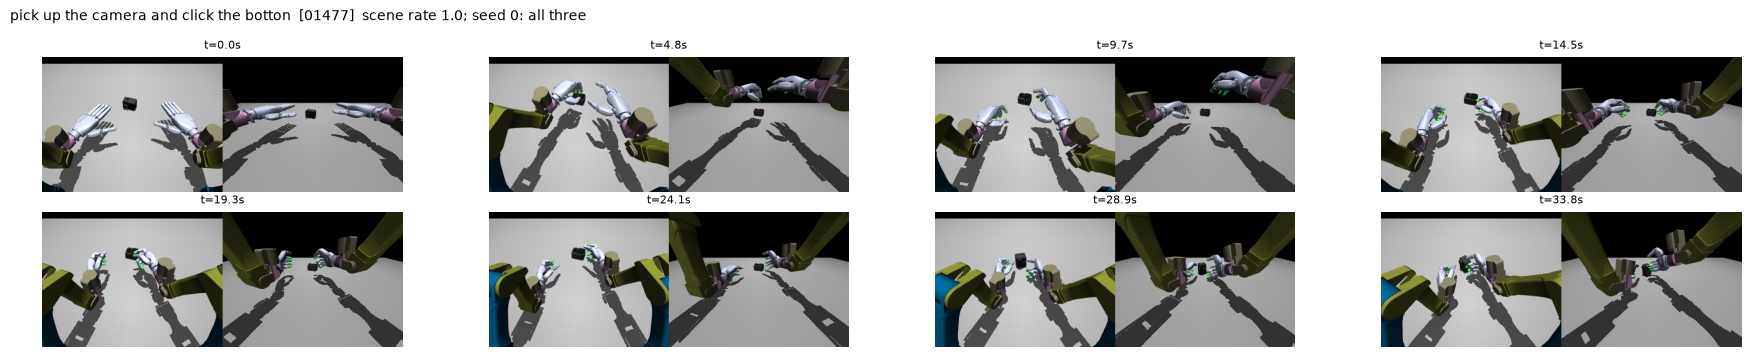

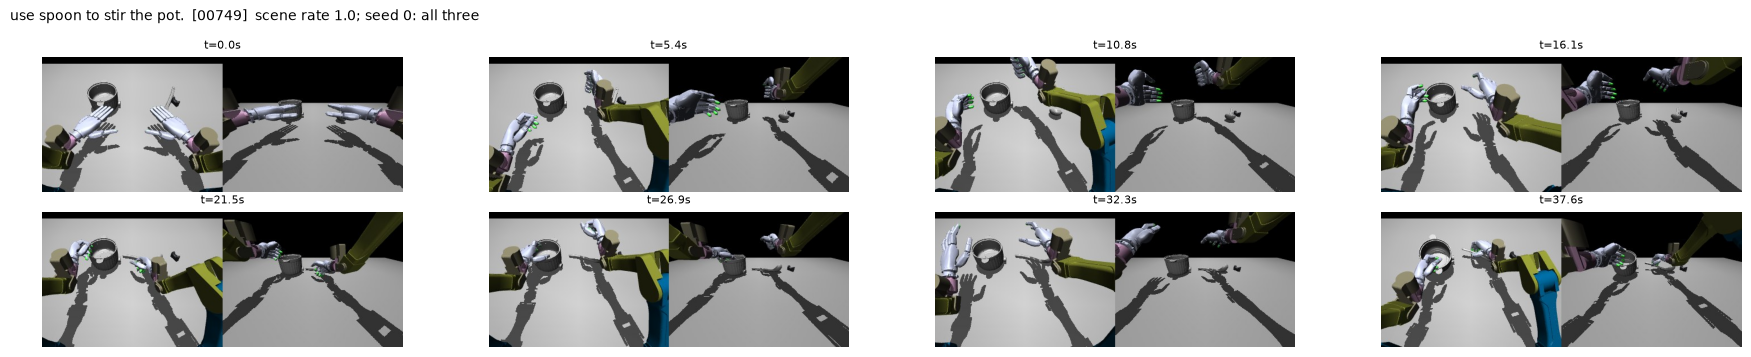

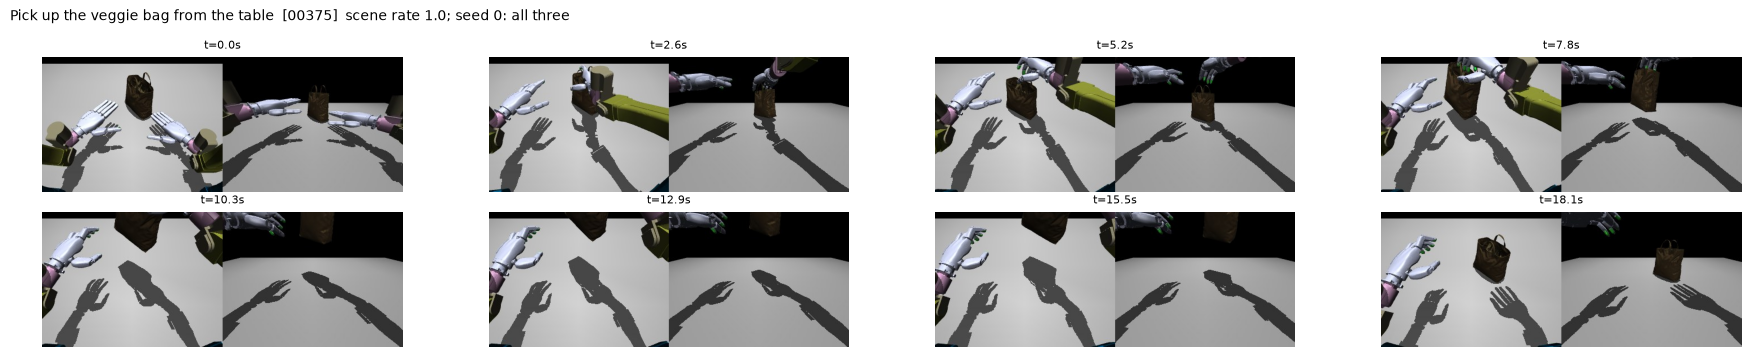

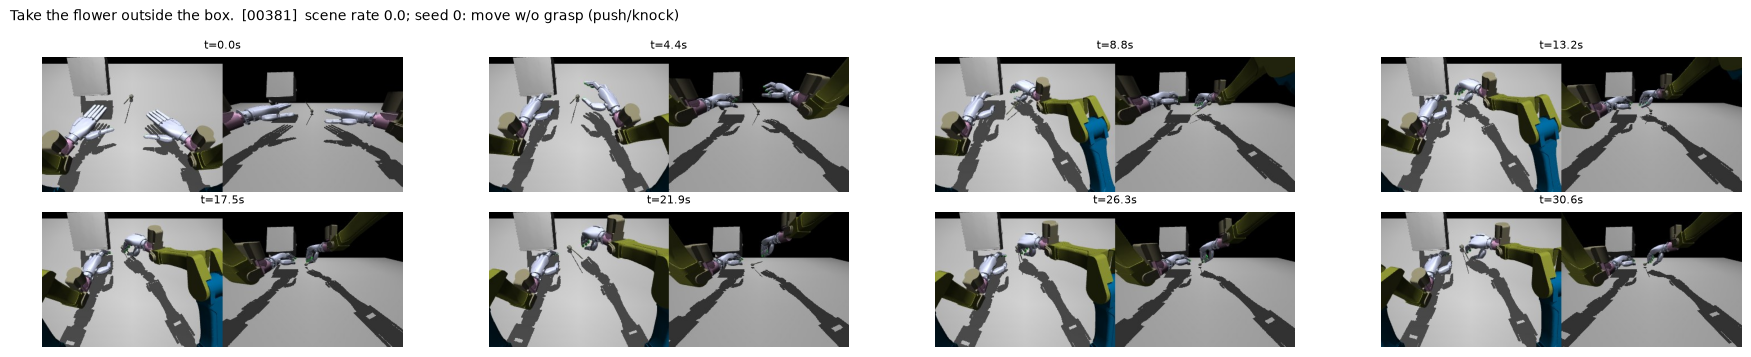

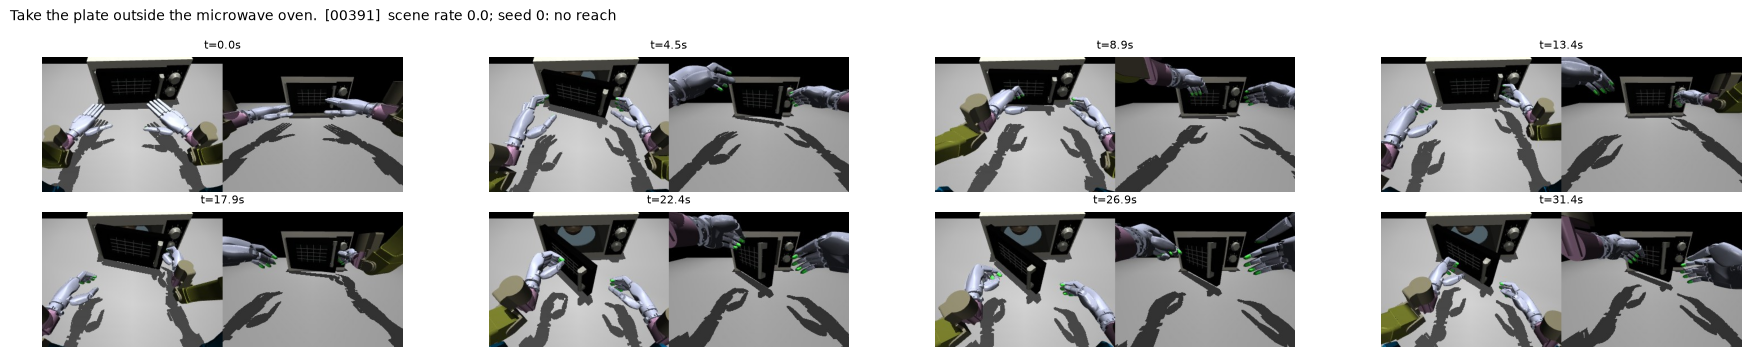

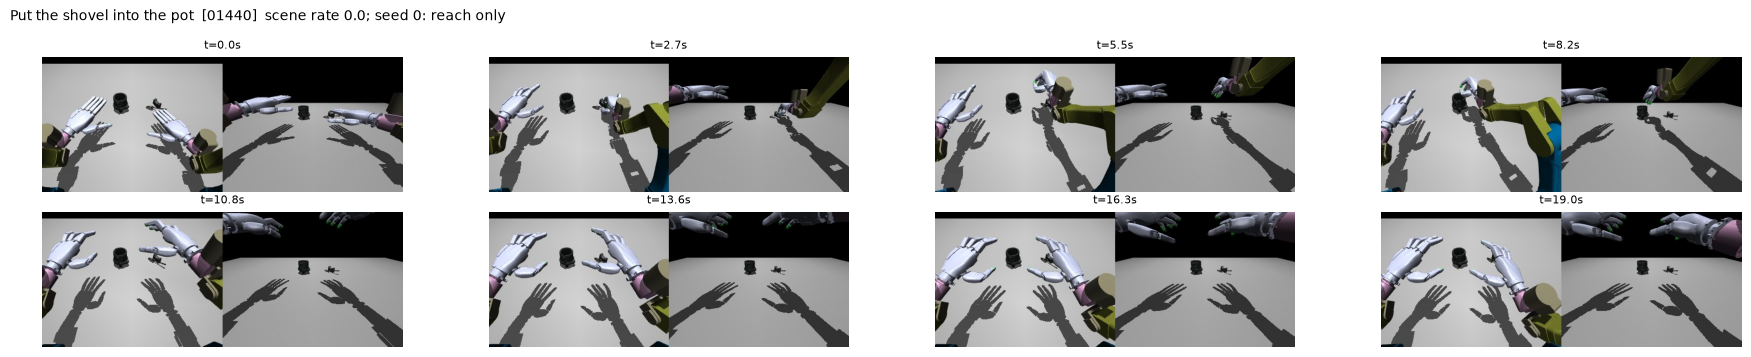

In [9]:
from PIL import Image
full = summ[(summ.n >= 0.95 * 58 * summ.seeds) & (summ.n >= 58)]  # tags whose seeds are complete
best_tag = full.sort_values('all3').iloc[-1]
sub = df[(df.run == best_tag.run) & (df.tag == best_tag.tag)]
rank = sub.groupby('scene').all3.mean().sort_values()
show = list(rank.index[-3:][::-1]) + list(rank.index[:3])
print(f'checkpoint: {best_tag.run} {best_tag.tag}')
for s in show:
    r = sub[(sub.scene == s)].sort_values('seed').iloc[0]
    kf = sorted(Path(r.dir, 'keyframes').glob('*.jpg'))[::2]
    if not kf:
        continue
    fig, axs = plt.subplots(2, 4, figsize=(18, 3.6))
    for ax, k in zip(axs.flat, kf):
        ax.imshow(Image.open(k)); ax.axis('off'); ax.set_title(f't={float(k.stem[1:]):.1f}s', fontsize=8)
    for ax in list(axs.flat)[len(kf):]:
        ax.axis('off')
    fig.suptitle(f'{TASKS[s]["task"]}  [{s[:5]}]  scene rate {rank[s]:.1f}; seed {r.seed}: {r.outcome}', fontsize=10, x=0.01, ha='left')
    plt.tight_layout()
    plt.show()

## Videos: best and worst scenes
Same checkpoint and scenes as above, seed 0, ego view on the left and chest view on the right. Videos are embedded, so they play anywhere the notebook opens. For every scene, see the review page or `<rollout>/video.mp4`.

In [10]:
import base64, subprocess, tempfile
from IPython.display import HTML
import imageio_ffmpeg
FF = imageio_ffmpeg.get_ffmpeg_exe()
cards = []
for s in show:
    r = sub[(sub.scene == s)].sort_values('seed').iloc[0]
    v = Path(r.dir, 'video.mp4')
    if not v.exists():
        cards.append(f'<div style="width:480px"><b>{TASKS[s]["task"]}</b><br>video not rendered yet</div>'); continue
    with tempfile.NamedTemporaryFile(suffix='.mp4') as t:
        subprocess.run([FF, '-y', '-loglevel', 'error', '-i', str(v), '-c:v', 'libx264', '-crf', '32', '-pix_fmt', 'yuv420p', t.name], check=True)
        b64 = base64.b64encode(open(t.name, 'rb').read()).decode()
    cards.append(f'<div style="width:480px;font:12px sans-serif"><b>{TASKS[s]["task"]}</b> [{s[:5]}]<br>'
                 f'scene rate {rank[s]:.1f}; seed {r.seed}: {r.outcome}<br>'
                 f'<video width="480" controls loop muted src="data:video/mp4;base64,{b64}"></video></div>')
HTML('<div style="display:flex;flex-wrap:wrap;gap:12px">' + ''.join(cards) + '</div>')